In [9]:
%idle_timeout 5
%worker_type Standard
%number_of_workers 2

You are already connected to a glueetl session 3483eec1-f254-4b3c-92ff-3ec54fdfadbd.

No change will be made to the current session that is set as glueetl. The session configuration change will apply to newly created sessions.


Current idle_timeout is 5 minutes.
idle_timeout has been set to 5 minutes.


You are already connected to a glueetl session 3483eec1-f254-4b3c-92ff-3ec54fdfadbd.

No change will be made to the current session that is set as glueetl. The session configuration change will apply to newly created sessions.


Previous worker type: Standard
Setting new worker type to: Standard


You are already connected to a glueetl session 3483eec1-f254-4b3c-92ff-3ec54fdfadbd.

No change will be made to the current session that is set as glueetl. The session configuration change will apply to newly created sessions.


Previous number of workers: 1
Setting new number of workers to: 2


In [2]:
%matplotlib notebook
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_palette("muted")
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, VectorAssembler
from pyspark.ml.stat import Correlation


ModuleNotFoundError: No module named 'wordcloud'


In [ ]:
spark = SparkSession.builder.appName("Amazon Product Data Exploration").getOrCreate()

# 1. Load Data

In [3]:
input_path = "s3://amazon-product-dataset-2024/cleaned/"

In [4]:
df = spark.read.parquet(input_path)

In [5]:
df.show()

+----------+--------------------+-----+-------+------------------+---------+-----------+------------+-----------------+-------------+
|      asin|               title|stars|reviews|             price|listPrice|category_id|isBestSeller|boughtInLastMonth|has_listPrice|
+----------+--------------------+-----+-------+------------------+---------+-----------+------------+-----------------+-------------+
|B09VX44LMP|Sweet Messenger T...|  4.7|     12|              62.0|      0.0|        118|       False|                0|        False|
|B0BS759SV5|Dori Crossbody, V...|  4.5|      0|             178.0|      0.0|        118|       False|                0|        False|
|B0B2PQVQF4|Theater Tote Bag ...|  4.5|      4|15.890000343322754|      0.0|        118|       False|                0|        False|
|B09J4D7GFX|Women Evening Han...|  4.6|    342|25.989999771118164|      0.0|        118|       False|                0|        False|
|B07DQX64XB|Vintage 1930 Upcy...|  4.7|    178|26.219999313354

In [6]:
df.describe().show()

+-------+--------------------+--------------------+-------------------+------------------+--------------------+------------------+------------------+------------+------------------+-------------+
|summary|                asin|               title|              stars|           reviews|               price|         listPrice|       category_id|isBestSeller| boughtInLastMonth|has_listPrice|
+-------+--------------------+--------------------+-------------------+------------------+--------------------+------------------+------------------+------------+------------------+-------------+
|  count|             1372587|             1372587|            1372587|           1372587|             1372587|           1372587|           1372587|     1372587|           1372587|      1372587|
|   mean|1.8160756785002997E9|3.846153846153846...|  4.378717478596322|183.20376850429153|  42.848201525974645|12.273176126736459|123.76410894172828|        null|143.43152747330407|         null|
| stddev|1.864481623

In [7]:
products_pd = df.toPandas()

In [8]:
bucket_name = 'amazon-product-dataset-2024'
categories_file_path = 's3://{}/amazon_categories.csv'.format(bucket_name)
categories_df = spark.read.csv(categories_file_path, header=True, inferSchema=True)
categories_df.show(5)

+---+--------------------+
| id|       category_name|
+---+--------------------+
|  1|Beading & Jewelry...|
|  2|   Fabric Decorating|
|  3|Knitting & Croche...|
|  4|Printmaking Supplies|
|  5|Scrapbooking & St...|
+---+--------------------+
only showing top 5 rows


In [9]:
categories_pd = categories_df.toPandas()

# 2. Univariate Distribution

### **`isBestSeller`**

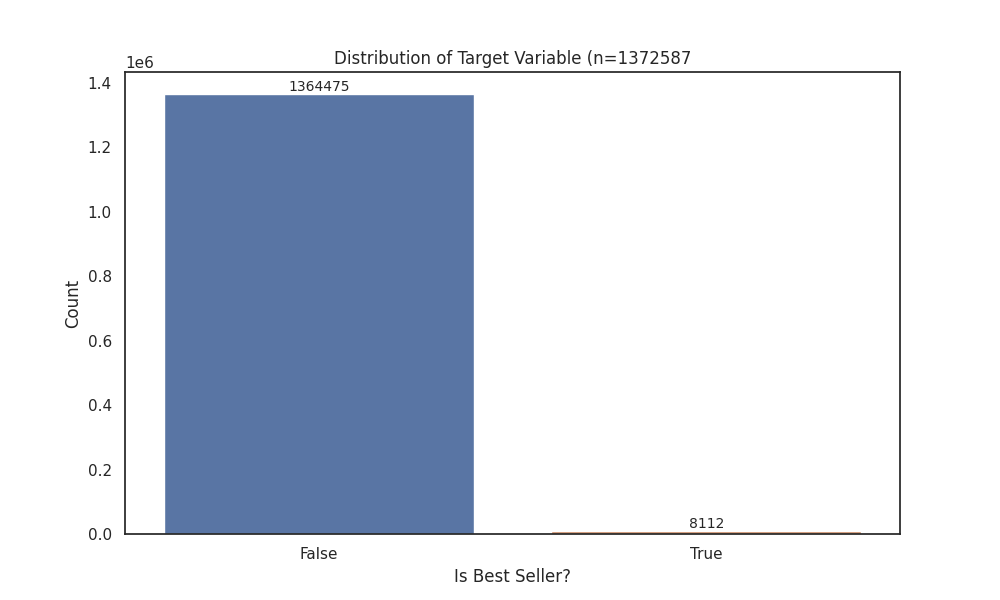

In [11]:
sns.set(style="white")
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='isBestSeller', data=products_pd)
plt.title('Distribution of Target Variable (n = 1372587)')
plt.xlabel('Is Best Seller?')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)
plt.show();
%matplot plt

### **`stars`**

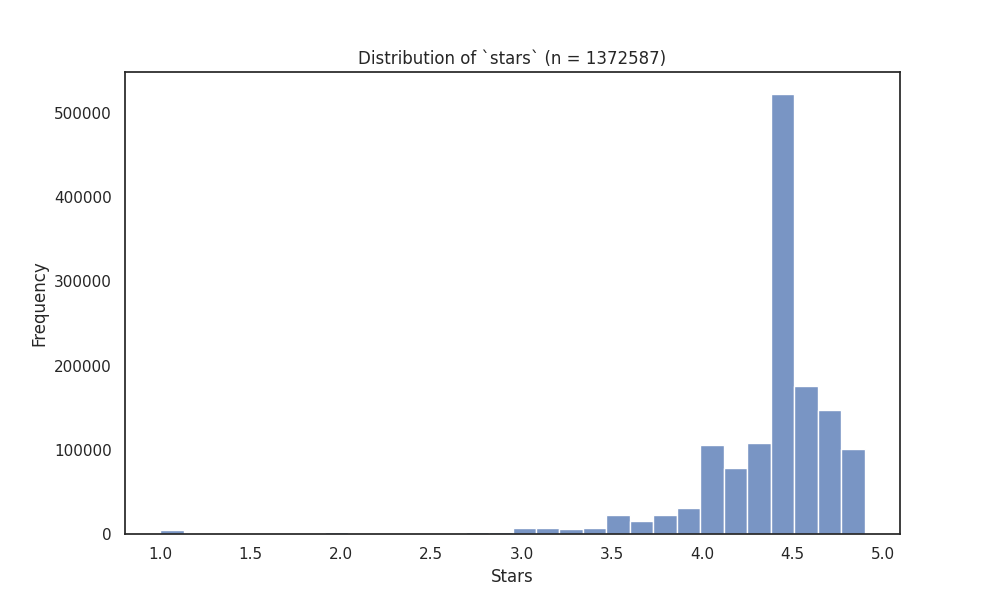

In [12]:
sns.set(style="white")
plt.figure(figsize=(10, 6))
sns.histplot(products_pd['stars'], bins=30)
plt.title('Distribution of `stars` (n = 1372587)')
plt.xlabel('Stars')
plt.ylabel('Frequency')
plt.show();
%matplot plt

### **`reviews`**

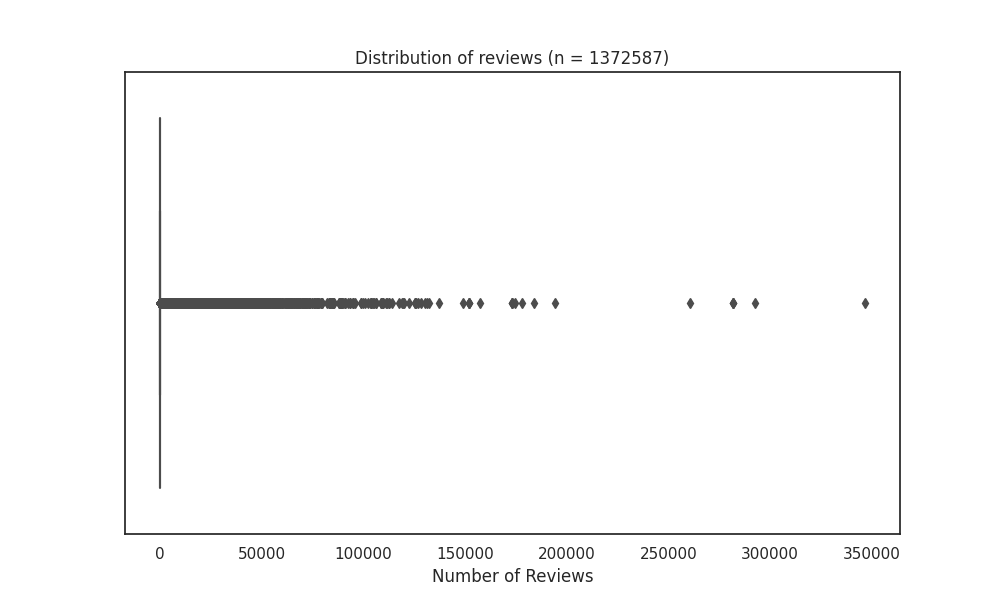

In [19]:
sns.set(style="white")
plt.figure(figsize=(10, 6))
sns.boxplot(x=products_pd['reviews'])
plt.title('Distribution of reviews (n = 1372587)')
plt.xlabel('Number of Reviews')
plt.show();
%matplot plt

### **`price`**

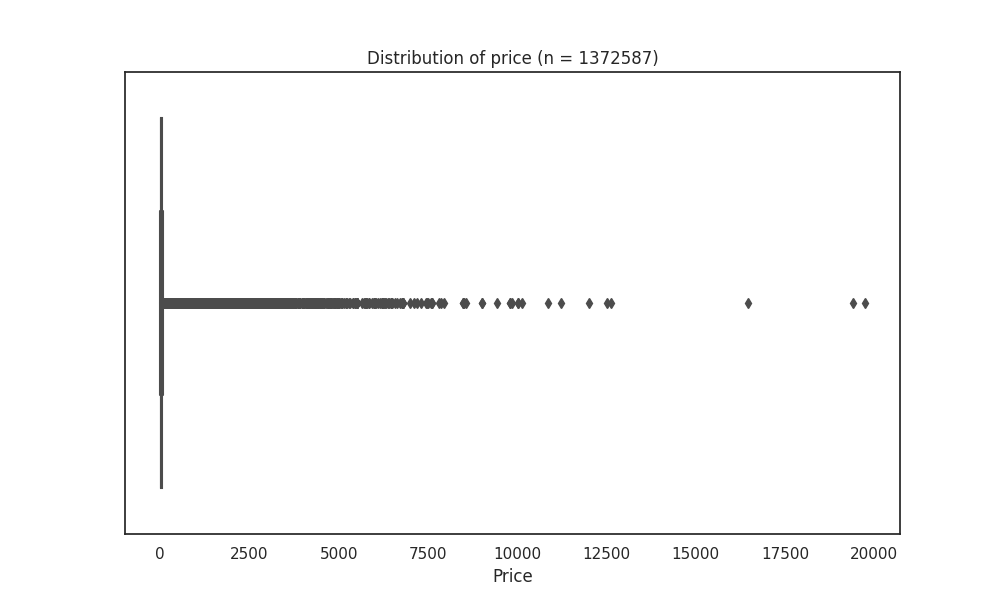

In [18]:
sns.set(style="white")
plt.figure(figsize=(10, 6))
sns.boxplot(x=products_pd['price'])
plt.title('Distribution of price (n = 1372587)')
plt.xlabel('Price')
plt.show();
%matplot plt

### **`listPrice`**

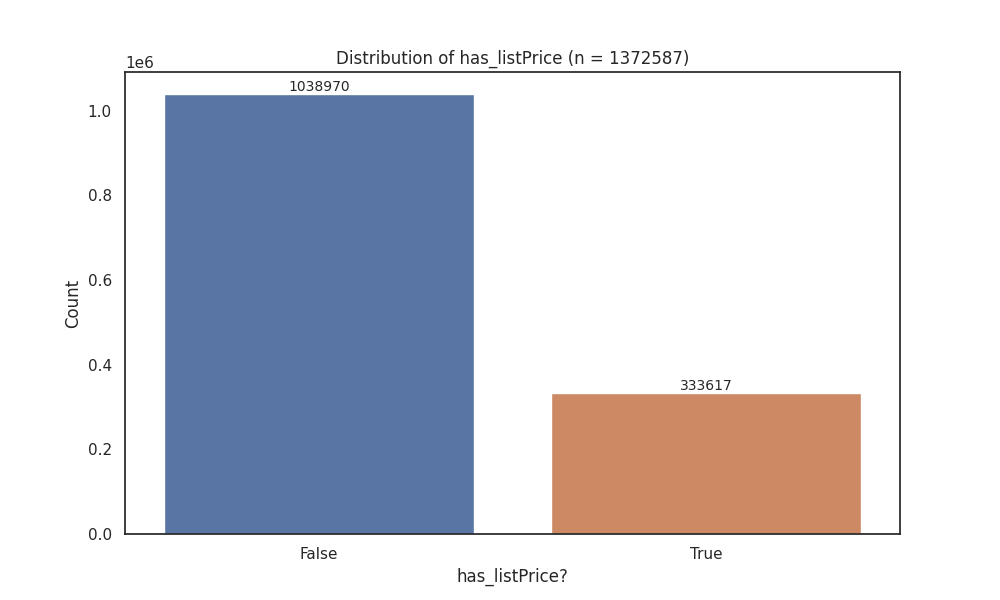

In [15]:
sns.set(style="white")
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='has_listPrice', data=products_pd)
plt.title('Distribution of has_listPrice (n = 1372587)')
plt.xlabel('has_listPrice?')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)
plt.show();
%matplot plt

### **`boughtInLastMonth`**

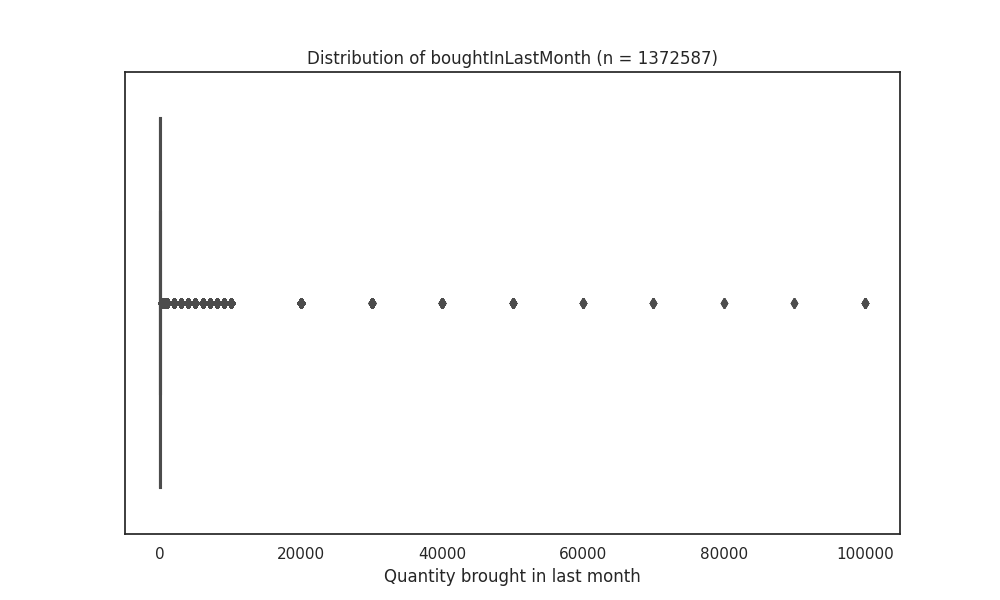

In [20]:
sns.set(style="white")
plt.figure(figsize=(10, 6))
sns.boxplot(x=products_pd['boughtInLastMonth'])
plt.title('Distribution of boughtInLastMonth (n = 1372587)')
plt.xlabel('Quantity brought in last month')
plt.show();
%matplot plt

## Decision on 'title' Feature

For our initial classification model predicting 'isBestSeller':

- We've decided to exclude the 'title' feature due to its unstructured nature and potential for introducing noise.
- Rationale:
  1. Reduces risk of overfitting to specific, possibly irrelevant, words in titles.
  2. Simplifies the model and reduces computational complexity.
  3. Avoids potential issues with "weird values" that might affect model performance.

Future considerations:
- If initial model performance is unsatisfactory, we may revisit 'title' with careful preprocessing:
  * Text cleaning and normalization
  * Feature extraction (e.g., title length, word count, keyword presence)
  * Advanced NLP techniques (TF-IDF, word embeddings)
- Any inclusion of 'title'-derived features will be accompanied by comparative analysis to justify their addition.

Remember: Sometimes, simpler models with cleaner, more structured data perform better. We can always add complexity if needed.

# 3. Relationship Analysis

#### a) Correlation Analysis

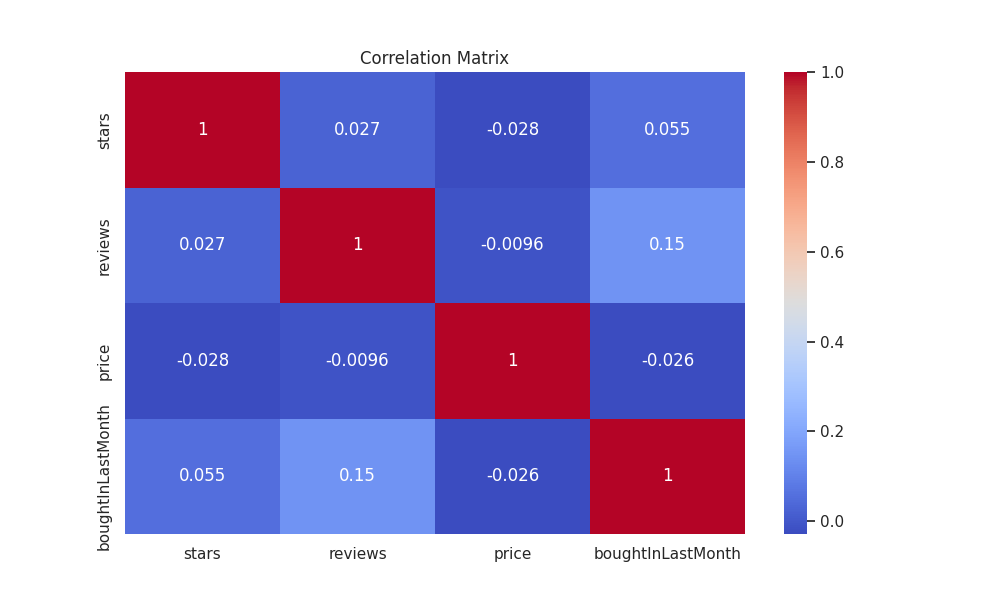

In [32]:
correlation_mat = products_pd[['stars', 'reviews', 'price', 'boughtInLastMonth']].corr()
plt.clf()
sns.heatmap(correlation_mat, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show();
%matplot plt

#### b) Pairplot of Numeric Variables

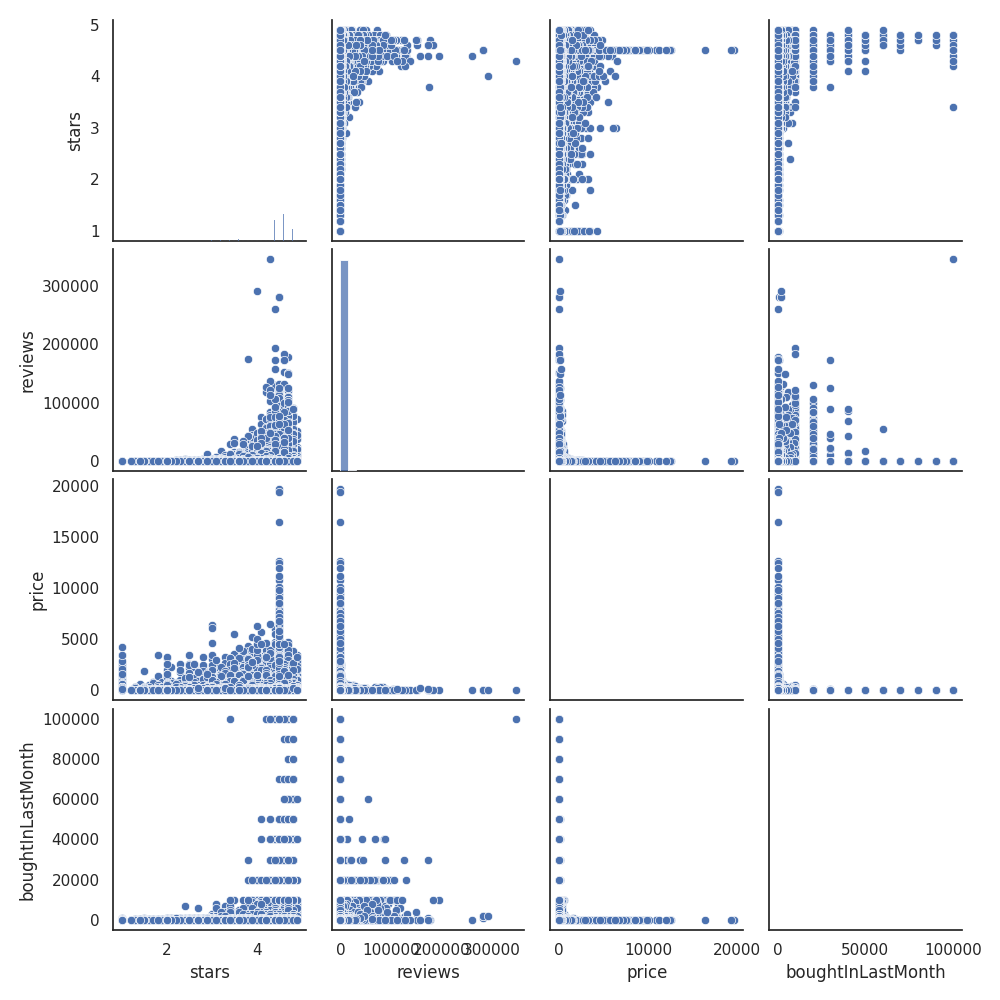

In [34]:
sns.pairplot(products_pd[['stars', 'reviews', 'price', 'boughtInLastMonth']])
plt.show();
%matplot plt

#### c) Boxplot of numeric variables for each label (target variable: isBestSeller)

In [ ]:
sns.set(style="white")
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
sns.boxplot(data=products_pd, x='isBestSeller', y='stars')
plt.title('Boxplot of Stars by isBestSeller (n = 1372587)')
plt.xlabel('Is Best Seller')
plt.ylabel('Stars')
plt.show();
%matplot plt

Execution Interrupted. Attempting to cancel the statement (statement_id=13)


#### c) Identify most common keywords from `title` column associated with best sellers 

- Tokenize the product title into individual words (tokens).
- Identify frequent words (keywords) in the product titles.
- One-Hot Encode or Count the Occurrences of these keywords in the title.
- Calculate correlation or feature importance between these keywords and the isBestSeller column.

In [1]:
# Tokenize


# Tokenize the product title into individual words
tokenizer = Tokenizer(inputCol="title", outputCol="title_tokens")
df = tokenizer.transform(df)

# Show the tokenized titles
df.select("title", "title_tokens").show()


4

In [ ]:
# Remove stopwords
# Remove common stopwords from the title tokens
remover = StopWordsRemover(inputCol="title_tokens", outputCol="filtered_tokens")
df = remover.transform(df)
# Show the filtered tokens
df.select("title", "filtered_tokens").show(truncate=False)

In [ ]:
# Identify frequent words
# Fit a CountVectorizer model to extract word counts
cv = CountVectorizer(inputCol="filtered_tokens", outputCol="title_features", vocabSize=50, minDF=5)
cv_model = cv.fit(df)
df = cv_model.transform(df)

# Show the top 50 most frequent words (keywords)
vocab = cv_model.vocabulary
print("Top 50 Keywords: ", vocab)

In [ ]:
df = df.withColumn("isBestSeller", col("isBestSeller").cast("int"))

In [ ]:
# Find correlation with bestsellers
# Assemble keyword columns into a feature vector
keyword_cols = [f'contains_{keyword}' for keyword in vocab]
assembler = VectorAssembler(inputCols=keyword_cols, outputCol="keyword_vector")
df = assembler.transform(df)


# Calculate the correlation matrix between keywords and the 'isBestSeller' column
corr_matrix = Correlation.corr(df.select("keyword_vector", "isBestSeller"), "keyword_vector").head()


# Display the correlation values
corr_values = corr_matrix[0].toArray()[-1]   # Correlations with 'isBestSeller' are in the last row

# Show correlations for each keyword
keyword_correlations = list(zip(vocab, corr_values))
keyword_correlations = sorted(keyword_correlations, key=lambda x: abs(x[1]), reverse=True)  # Sort by correlation
for keyword, corr in keyword_correlations:
    print(f"Keyword: {keyword}, Correlation with BestSeller: {corr}")